In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("data.csv")

print(df.shape)
print(df["Return_Status"].value_counts())
print(df["Return_Status"].value_counts(normalize=True))

(5000, 23)
Return_Status
Not Returned    3550
Returned        1450
Name: count, dtype: int64
Return_Status
Not Returned    0.71
Returned        0.29
Name: proportion, dtype: float64


In [3]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

df["Order_Month"] = df["Order_Date"].dt.month
df["Order_DayOfWeek"] = df["Order_Date"].dt.dayofweek
df["Is_Weekend"] = (
    df["Order_DayOfWeek"] >= 5
).astype(int)

In [4]:
features = [
    "Product_Category",
    "Product_Price",
    "Order_Quantity",
    "Discount_Applied",
    "Shipping_Method",
    "Payment_Method",
    "User_Age",
    "User_Gender",
    "User_Location",
    "Order_Month",
    "Order_DayOfWeek",
    "Is_Weekend"
]

X = df[features]
y = df["Return_Status"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
categorical_features = (
    X.select_dtypes(include="object")
    .columns
    .tolist()
)

numeric_features = (
    X.select_dtypes(exclude="object")
    .columns
    .tolist()
)

In [7]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [8]:
model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=500,
            max_depth=12,
            min_samples_split=8,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions,
    pos_label="Returned"
)

recall = recall_score(
    y_test,
    predictions,
    pos_label="Returned"
)

f1 = f1_score(
    y_test,
    predictions,
    pos_label="Returned"
)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy  : 63.00%
Precision : 38.89%
Recall    : 48.28%
F1 Score  : 43.08%

Classification Report:
              precision    recall  f1-score   support

Not Returned       0.77      0.69      0.73       710
    Returned       0.39      0.48      0.43       290

    accuracy                           0.63      1000
   macro avg       0.58      0.59      0.58      1000
weighted avg       0.66      0.63      0.64      1000



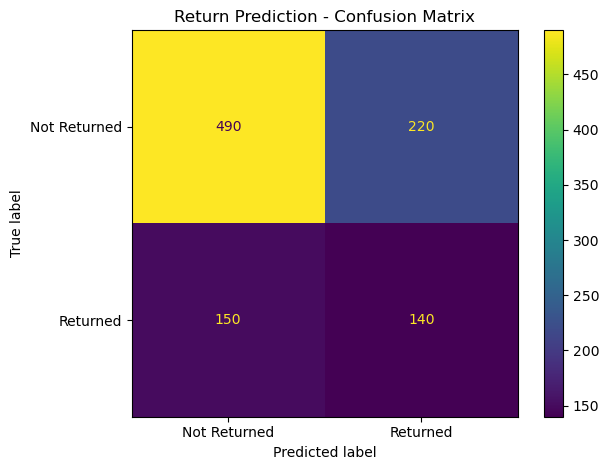

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.title(
    "Return Prediction - Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [11]:
def predict_return(
    product_category,
    product_price,
    order_quantity,
    discount_applied,
    shipping_method,
    payment_method,
    user_age,
    user_gender,
    user_location,
    order_date
):

    order_date = pd.to_datetime(order_date)

    new_order = pd.DataFrame({
        "Product_Category": [product_category],
        "Product_Price": [product_price],
        "Order_Quantity": [order_quantity],
        "Discount_Applied": [discount_applied],
        "Shipping_Method": [shipping_method],
        "Payment_Method": [payment_method],
        "User_Age": [user_age],
        "User_Gender": [user_gender],
        "User_Location": [user_location],

        "Order_Month": [
            order_date.month
        ],

        "Order_DayOfWeek": [
            order_date.dayofweek
        ],

        "Is_Weekend": [
            int(
                order_date.dayofweek >= 5
            )
        ]
    })

    prediction = model.predict(
        new_order
    )[0]

    probabilities = model.predict_proba(
        new_order
    )[0]

    probability_dict = dict(
        zip(
            model.classes_,
            probabilities
        )
    )

    print(
        "Prediction:",
        prediction
    )

    print(
        "Return Probability:",
        f"{probability_dict['Returned'] * 100:.2f}%"
    )

    print(
        "Not Returned Probability:",
        f"{probability_dict['Not Returned'] * 100:.2f}%"
    )

    return prediction

In [12]:
predict_return(
    product_category="Clothing",
    product_price=1200,
    order_quantity=2,
    discount_applied=20,
    shipping_method="Standard",
    payment_method="Credit Card",
    user_age=25,
    user_gender="Female",
    user_location="Chennai",
    order_date="2026-08-30"
)

Prediction: Returned
Return Probability: 56.88%
Not Returned Probability: 43.12%


'Returned'